# Evaluación Formativa 2 — Práctica de Modelamiento Predictivo

## Predicción de lluvia del día siguiente en Australia

**Curso:** MCDI501 — Estadística Computacional para la Toma de Decisiones  
**Fase:** 3 — Desarrollo del proyecto  
**Integrantes:** Enzo Pinilla · Claudio Alarcón · Luis Rodrigo Espinoza  
**Docente:** Dr. Jean Paul Maidana González  
**Dataset:** WeatherAUS / Rain in Australia  
**Repositorio:** https://github.com/sauriomac/mcdi501-estadistica-computacional-grupo2  
**Fecha:** 10 de julio de 2026

---

### Propósito

Este notebook desarrolla el flujo completo solicitado para la Formativa 2: preparación de datos, integración explícita de los resultados de S1 y S2, selección fundamentada de predictores, ajuste de una regresión logística, interpretación de coeficientes y *odds ratios*, diagnóstico mediante VIF y evaluación sobre un conjunto de prueba con matriz de confusión, métricas y curva ROC-AUC.

La variable objetivo es `RainTomorrow`: **1 = llueve al día siguiente** y **0 = no llueve**.

## 0. Criterios de reproducibilidad

- Semilla fija: `42`.
- El notebook busca `weatherAUS.csv` en rutas relativas del repositorio.
- Si el archivo local no está disponible, utiliza un espejo público como respaldo.
- La imputación y la estandarización se ajustan **solo con entrenamiento**, para evitar fuga de información.
- La partición es 70 % entrenamiento y 30 % prueba, estratificada por la variable objetivo.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    roc_curve,
    roc_auc_score,
    average_precision_score,
)
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")

REPO_ROOT = next(
    (root for root in [Path.cwd(), *Path.cwd().parents] if (root / "data").exists() and (root / "notebooks").exists()),
    Path.cwd().parent,
)
FIGURES_DIR = REPO_ROOT / "results" / "figures_f2"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "font.size": 10,
})

print(f"Semilla fijada: {SEED}")

Semilla fijada: 42


# 1. Preparación de datos

## 1.1 Carga del dataset

Se reutiliza el mismo conjunto empleado en S1 y S2. El archivo original contiene observaciones meteorológicas diarias de distintas estaciones australianas. Antes del modelamiento se eliminan únicamente los registros sin variable objetivo, porque no pueden participar en un problema supervisado.

> **Control de fuga:** algunos espejos antiguos incluyen `RISK_MM`, una medida del día siguiente utilizada para derivar `RainTomorrow`. Si aparece, se elimina inmediatamente porque revelaría información futura.

In [2]:
# Búsqueda reproducible en el repositorio y carpetas superiores
candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
candidate_paths = []
for root in candidate_roots:
    candidate_paths.extend([
        root / "data" / "raw" / "weatherAUS.csv",
        root / "weatherAUS.csv",
    ])

DATA_PATH = next((p for p in candidate_paths if p.exists()), None)
FALLBACK_URL = (
    "https://raw.githubusercontent.com/tvdboom/ATOM/"
    "master/examples/datasets/weatherAUS.csv"
)

if DATA_PATH is not None:
    df_raw = pd.read_csv(DATA_PATH)
    data_source = str(DATA_PATH)
else:
    df_raw = pd.read_csv(FALLBACK_URL)
    data_source = "espejo público de respaldo"

print(f"Fuente utilizada: {data_source}")
print(f"Dimensiones cargadas: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas")
display(df_raw.head())

Fuente utilizada: /Users/sauriomac/mcdi501-estadistica-computacional-grupo2/data/raw/weatherAUS.csv
Dimensiones cargadas: 145,460 filas × 23 columnas


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4000,22.9000,0.6000,NaN,NaN,W,44.0000,W,WNW,20.0000,24.0000,71.0000,22.0000,"1,007.7000","1,007.1000",8.0000,NaN,16.9000,21.8000,No,No
1,2008-12-02,Albury,7.4000,25.1000,0.0000,NaN,NaN,WNW,44.0000,NNW,WSW,4.0000,22.0000,44.0000,25.0000,"1,010.6000","1,007.8000",NaN,NaN,17.2000,24.3000,No,No
2,2008-12-03,Albury,12.9000,25.7000,0.0000,NaN,NaN,WSW,46.0000,W,WSW,19.0000,26.0000,38.0000,30.0000,"1,007.6000","1,008.7000",NaN,2.0000,21.0000,23.2000,No,No
3,2008-12-04,Albury,9.2000,28.0000,0.0000,NaN,NaN,NE,24.0000,SE,E,11.0000,9.0000,45.0000,16.0000,"1,017.6000","1,012.8000",NaN,NaN,18.1000,26.5000,No,No
4,2008-12-05,Albury,17.5000,32.3000,1.0000,NaN,NaN,W,41.0000,ENE,NW,7.0000,20.0000,82.0000,33.0000,"1,010.8000","1,006.0000",7.0000,8.0000,17.8000,29.7000,No,No


In [3]:
# Eliminación preventiva de una variable que produciría fuga de información
leakage_columns = [c for c in ["RISK_MM"] if c in df_raw.columns]
if leakage_columns:
    df_raw = df_raw.drop(columns=leakage_columns)
    print(f"Variables eliminadas por fuga de información: {leakage_columns}")
else:
    print("No se detectaron variables conocidas de fuga de información.")

# Normalización robusta del objetivo, compatible con Yes/No o 0/1
TARGET = "RainTomorrow"
if TARGET not in df_raw.columns:
    raise KeyError(f"No se encontró la variable objetivo {TARGET!r}.")

target_non_null = df_raw[TARGET].dropna()
if set(target_non_null.unique()).issubset({"Yes", "No"}):
    valid_target_mask = df_raw[TARGET].isin(["Yes", "No"])
    df = df_raw.loc[valid_target_mask].copy()
    df["RainTomorrow_bin"] = df[TARGET].map({"No": 0, "Yes": 1}).astype(int)
elif set(pd.to_numeric(target_non_null, errors="coerce").dropna().unique()).issubset({0, 1}):
    target_numeric = pd.to_numeric(df_raw[TARGET], errors="coerce")
    valid_target_mask = target_numeric.isin([0, 1])
    df = df_raw.loc[valid_target_mask].copy()
    df["RainTomorrow_bin"] = target_numeric.loc[valid_target_mask].astype(int)
else:
    raise ValueError("RainTomorrow no está codificada como Yes/No ni como 0/1.")

n_target_missing = len(df_raw) - len(df)
print(f"Registros sin objetivo excluidos: {n_target_missing:,}")
print(f"Muestra válida para modelamiento: {len(df):,} filas")
print("Distribución del objetivo:")
display(
    df["RainTomorrow_bin"]
      .value_counts()
      .sort_index()
      .rename(index={0: "No", 1: "Yes"})
      .to_frame("frecuencia")
      .assign(porcentaje=lambda t: 100 * t["frecuencia"] / t["frecuencia"].sum())
)

No se detectaron variables conocidas de fuga de información.


Registros sin objetivo excluidos: 3,267
Muestra válida para modelamiento: 142,193 filas
Distribución del objetivo:


,frecuencia,porcentaje
RainTomorrow_bin,,
No,110316,77.5819
Yes,31877,22.4181


## 1.2 Hallazgos heredados de S1

S1 estableció el diagnóstico exploratorio e inferencial que condiciona este modelo:

- La clase `RainTomorrow=Yes` representa aproximadamente **22,4 %**, por lo que existe desbalance moderado.
- `Humidity3pm`, `RainToday`, `Humidity9am`, `Pressure9am`, `Rainfall` y `WindGustSpeed` mostraron las asociaciones lineales más relevantes con el objetivo.
- `MaxTemp` y `Temp3pm` tienen una correlación cercana a **0,985**; no deben incorporarse juntas sin control de colinealidad.
- `Sunshine` y `Evaporation` poseen alrededor de **48 %** y **43 %** de datos faltantes.
- `Rainfall` presenta asimetría y curtosis extremas; `WindGustSpeed` también tiene cola derecha y valores extremos.

In [4]:
hallazgos_s1 = pd.DataFrame([
    ["RainTomorrow=Yes", "22,42 % de casos válidos", "Evaluar métricas de la clase positiva; no depender solo de accuracy"],
    ["Humidity3pm", "r ≈ 0,446 con RainTomorrow", "Candidata principal; asociación positiva"],
    ["RainToday_bin", "r ≈ 0,313", "Señal reciente de precipitación"],
    ["Humidity9am", "r ≈ 0,257", "Asociación positiva, aunque parcialmente redundante con Humidity3pm"],
    ["Pressure9am", "r ≈ -0,246", "Asociación negativa"],
    ["Rainfall", "r ≈ 0,239; asimetría ≈ 9,84", "Transformación log1p; no eliminar lluvia positiva con regla IQR"],
    ["WindGustSpeed", "r ≈ 0,234; cola pesada", "Imputación robusta y estandarización"],
    ["MaxTemp / Temp3pm", "r ≈ 0,985 entre ambas", "No utilizarlas simultáneamente"],
    ["Sunshine / Evaporation", "≈48 % / ≈43 % faltantes", "Excluir del modelo formativo básico"],
], columns=["Elemento", "Resultado S1", "Consecuencia para F2"])

display(hallazgos_s1)

,Elemento,Resultado S1,Consecuencia para F2
0,RainTomorrow=Yes,"22,42 % de casos válidos",Evaluar métricas de la clase positiva; no depe...
1,Humidity3pm,"r ≈ 0,446 con RainTomorrow",Candidata principal; asociación positiva
2,RainToday_bin,"r ≈ 0,313",Señal reciente de precipitación
3,Humidity9am,"r ≈ 0,257","Asociación positiva, aunque parcialmente redun..."
4,Pressure9am,"r ≈ -0,246",Asociación negativa
5,Rainfall,"r ≈ 0,239; asimetría ≈ 9,84",Transformación log1p; no eliminar lluvia posit...
6,WindGustSpeed,"r ≈ 0,234; cola pesada",Imputación robusta y estandarización
7,MaxTemp / Temp3pm,"r ≈ 0,985 entre ambas",No utilizarlas simultáneamente
8,Sunshine / Evaporation,≈48 % / ≈43 % faltantes,Excluir del modelo formativo básico


## 1.3 Hallazgos heredados de S2

S2 validó mediante bootstrap que las asociaciones de `Humidity3pm`, `RainToday_bin`, `Humidity9am`, `Pressure9am` y `Rainfall` conservan su signo y sus intervalos no incluyen cero. También confirmó que los intervalos clásicos y bootstrap de varios parámetros son prácticamente equivalentes.

Para las colas pesadas, S2 mostró que una regla IQR puede marcar cerca de 18 % de `Rainfall` debido a la concentración de ceros. Por ello, esos valores no se tratan automáticamente como errores: se utiliza `log1p(Rainfall)`, coherente con la recomendación robusta previa.

In [5]:
correlaciones_s2 = pd.DataFrame([
    ["Humidity3pm", 0.4462, 0.4418, 0.4505, "Estable"],
    ["RainToday_bin", 0.3131, 0.3074, 0.3189, "Estable"],
    ["Humidity9am", 0.2572, 0.2526, 0.2616, "Estable"],
    ["Pressure9am", -0.2464, -0.2516, -0.2411, "Estable"],
    ["Rainfall", 0.2390, 0.2319, 0.2462, "Estable"],
], columns=["Variable", "r observado", "IC95 inferior", "IC95 superior", "Conclusión"])

display(correlaciones_s2)

parametros_robustos_s2 = pd.DataFrame([
    ["Media Humidity3pm", 51.5391, "IC clásico ≈ IC bootstrap"],
    ["Media WindGustSpeed", 40.0352, "Estable, con sensibilidad moderada a extremos"],
    ["Media Rainfall", 2.3609, "Requiere cautela por cero-inflación y cola pesada"],
    ["Proporción RainTomorrow=Yes", 0.2242, "Wilson ≈ bootstrap; confirma desbalance"],
], columns=["Parámetro", "Estimación S2", "Lectura"])

display(parametros_robustos_s2)

,Variable,r observado,IC95 inferior,IC95 superior,Conclusión
0,Humidity3pm,0.4462,0.4418,0.4505,Estable
1,RainToday_bin,0.3131,0.3074,0.3189,Estable
2,Humidity9am,0.2572,0.2526,0.2616,Estable
3,Pressure9am,-0.2464,-0.2516,-0.2411,Estable
4,Rainfall,0.2390,0.2319,0.2462,Estable


,Parámetro,Estimación S2,Lectura
0,Media Humidity3pm,51.5391,IC clásico ≈ IC bootstrap
1,Media WindGustSpeed,40.0352,"Estable, con sensibilidad moderada a extremos"
2,Media Rainfall,2.3609,Requiere cautela por cero-inflación y cola pesada
3,Proporción RainTomorrow=Yes,0.2242,Wilson ≈ bootstrap; confirma desbalance


## 1.4 Selección de variables y tratamiento

Se seleccionan **cinco** predictores:

1. `Humidity3pm`: asociación estable más alta.
2. `RainToday_bin`: correlación estable y señal meteorológica inmediatamente anterior.
3. `Pressure9am`: asociación estable negativa.
4. `Rainfall_log1p`: correlación estable, transformada por su cola pesada y concentración de ceros.
5. `WindGustSpeed`: asociación relevante en S1 y parámetro validado en S2; agrega una dimensión física distinta de humedad, presión y lluvia.

`Humidity9am` se reserva para S3: aunque su correlación marginal es estable, se limita el modelo a cinco variables y se evita duplicar en exceso información de humedad ya representada por `Humidity3pm`.

### Estrategia de faltantes

- Predictores continuos: **mediana**, por robustez frente a asimetría y extremos.
- `RainToday_bin`: **moda**, por ser binaria.
- Los parámetros de imputación se estiman únicamente en entrenamiento.
- Las variables continuas se estandarizan; la variable binaria se conserva en 0/1.

In [6]:
# Codificación de RainToday compatible con Yes/No o 0/1
if "RainToday" not in df.columns:
    raise KeyError("No se encontró RainToday.")

rain_today_non_null = df["RainToday"].dropna()
if set(rain_today_non_null.unique()).issubset({"Yes", "No"}):
    df["RainToday_bin"] = df["RainToday"].map({"No": 0, "Yes": 1})
else:
    df["RainToday_bin"] = pd.to_numeric(df["RainToday"], errors="coerce")

# Transformación robusta indicada por S2
if (df["Rainfall"].dropna() < 0).any():
    raise ValueError("Rainfall contiene valores negativos; se requiere revisar el dominio.")
df["Rainfall_log1p"] = np.log1p(df["Rainfall"])

FEATURES = [
    "Humidity3pm",
    "RainToday_bin",
    "Pressure9am",
    "Rainfall_log1p",
    "WindGustSpeed",
]
CONTINUOUS_FEATURES = [
    "Humidity3pm",
    "Pressure9am",
    "Rainfall_log1p",
    "WindGustSpeed",
]
BINARY_FEATURES = ["RainToday_bin"]

missing_report = pd.DataFrame({
    "faltantes": df[FEATURES].isna().sum(),
    "porcentaje": 100 * df[FEATURES].isna().mean(),
}).sort_values("porcentaje", ascending=False)

display(missing_report)

,faltantes,porcentaje
Pressure9am,14014,9.8556
WindGustSpeed,9270,6.5193
Humidity3pm,3610,2.5388
RainToday_bin,1406,0.9888
Rainfall_log1p,1406,0.9888


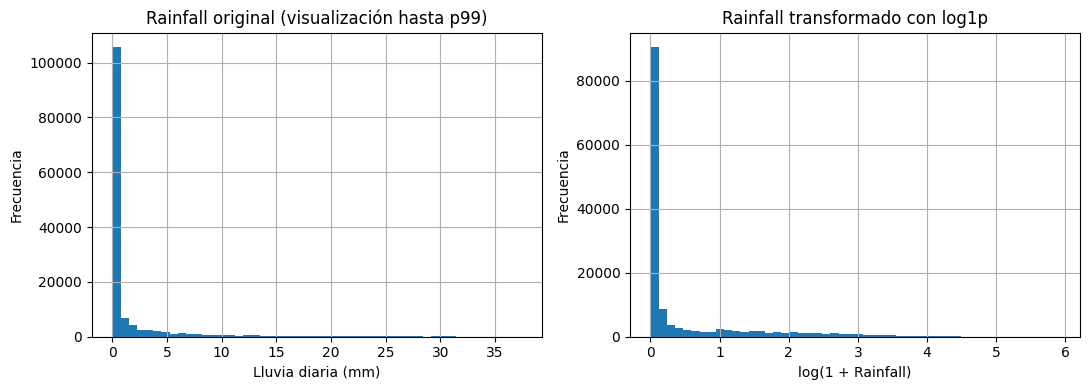

Rainfall: mediana = 0.0, p99 = 37.4, máximo = 371.0
La transformación reduce la dominancia visual de la cola sin borrar eventos reales de lluvia.


In [7]:
# Evidencia visual del tratamiento robusto aplicado a Rainfall
rain = df["Rainfall"].dropna()
p99 = rain.quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(rain[rain <= p99], bins=50)
axes[0].set_title("Rainfall original (visualización hasta p99)")
axes[0].set_xlabel("Lluvia diaria (mm)")
axes[0].set_ylabel("Frecuencia")

axes[1].hist(np.log1p(rain), bins=50)
axes[1].set_title("Rainfall transformado con log1p")
axes[1].set_xlabel("log(1 + Rainfall)")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "rainfall_transform.png", dpi=180, bbox_inches="tight")
plt.show()

print(f"Rainfall: mediana = {rain.median():.1f}, p99 = {p99:.1f}, máximo = {rain.max():.1f}")
print("La transformación reduce la dominancia visual de la cola sin borrar eventos reales de lluvia.")

## 1.5 Partición 70/30 y preprocesamiento sin fuga

La partición se estratifica para conservar la proporción de días con lluvia en ambos subconjuntos. Después de dividir, se ajustan imputadores y estandarizador solo con entrenamiento.

In [8]:
X = df[FEATURES].copy()
y = df["RainTomorrow_bin"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y,
)

continuous_imputer = SimpleImputer(strategy="median")
binary_imputer = SimpleImputer(strategy="most_frequent")
scaler = StandardScaler()

# Ajuste solo con entrenamiento
X_train_cont_imp = continuous_imputer.fit_transform(X_train[CONTINUOUS_FEATURES])
X_test_cont_imp = continuous_imputer.transform(X_test[CONTINUOUS_FEATURES])

X_train_processed = pd.DataFrame(
    scaler.fit_transform(X_train_cont_imp),
    columns=CONTINUOUS_FEATURES,
    index=X_train.index,
)
X_test_processed = pd.DataFrame(
    scaler.transform(X_test_cont_imp),
    columns=CONTINUOUS_FEATURES,
    index=X_test.index,
)

X_train_processed["RainToday_bin"] = binary_imputer.fit_transform(
    X_train[["RainToday_bin"]]
).ravel()
X_test_processed["RainToday_bin"] = binary_imputer.transform(
    X_test[["RainToday_bin"]]
).ravel()

# Orden definitivo y tipo numérico
X_train_processed = X_train_processed[FEATURES].astype(float)
X_test_processed = X_test_processed[FEATURES].astype(float)

print(f"Entrenamiento: {len(X_train):,} observaciones ({len(X_train)/len(X):.1%})")
print(f"Prueba:        {len(X_test):,} observaciones ({len(X_test)/len(X):.1%})")
print(f"Proporción positiva en train: {y_train.mean():.4f}")
print(f"Proporción positiva en test:  {y_test.mean():.4f}")

imputation_values = pd.DataFrame({
    "variable": CONTINUOUS_FEATURES + BINARY_FEATURES,
    "valor_aprendido_en_train": list(continuous_imputer.statistics_) + list(binary_imputer.statistics_),
    "estrategia": ["mediana"] * len(CONTINUOUS_FEATURES) + ["moda"],
})
display(imputation_values)

assert X_train_processed.isna().sum().sum() == 0
assert X_test_processed.isna().sum().sum() == 0
assert abs(y_train.mean() - y_test.mean()) < 0.001
print("Controles superados: sin faltantes luego del procesamiento y estratificación conservada.")

Entrenamiento: 99,535 observaciones (70.0%)
Prueba:        42,658 observaciones (30.0%)
Proporción positiva en train: 0.2242
Proporción positiva en test:  0.2242


,variable,valor_aprendido_en_train,estrategia
0,Humidity3pm,52.0000,mediana
1,Pressure9am,"1,017.6000",mediana
2,Rainfall_log1p,0.0000,mediana
3,WindGustSpeed,39.0000,mediana
4,RainToday_bin,0.0000,moda


Controles superados: sin faltantes luego del procesamiento y estratificación conservada.


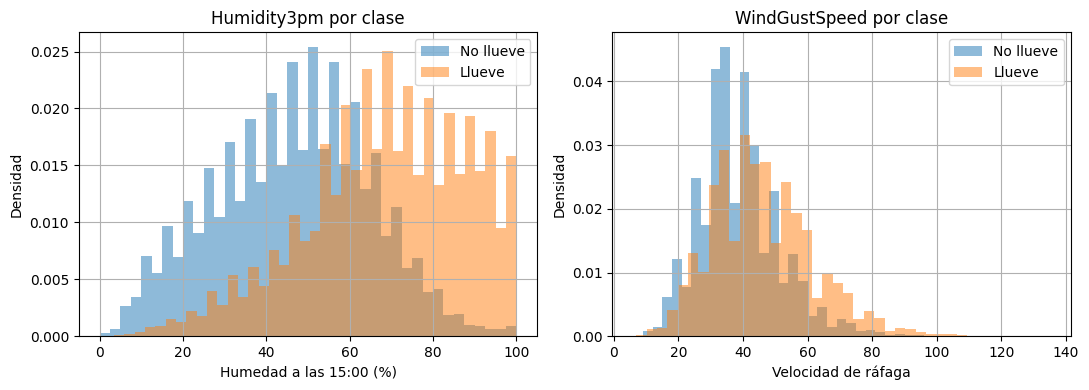

In [9]:
# Distribución de dos predictores por clase para contextualizar el modelo
plot_data = df[["Humidity3pm", "WindGustSpeed", "RainTomorrow_bin"]].dropna()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for class_value, label in [(0, "No llueve"), (1, "Llueve")]:
    subset = plot_data.loc[plot_data["RainTomorrow_bin"] == class_value]
    axes[0].hist(subset["Humidity3pm"], bins=40, density=True, alpha=0.5, label=label)
    axes[1].hist(subset["WindGustSpeed"], bins=40, density=True, alpha=0.5, label=label)

axes[0].set_title("Humidity3pm por clase")
axes[0].set_xlabel("Humedad a las 15:00 (%)")
axes[0].set_ylabel("Densidad")
axes[0].legend()

axes[1].set_title("WindGustSpeed por clase")
axes[1].set_xlabel("Velocidad de ráfaga")
axes[1].set_ylabel("Densidad")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "predictor_distributions.png", dpi=180, bbox_inches="tight")
plt.show()

# 2. Modelo de regresión logística

## 2.1 Ajuste

Se utiliza `statsmodels.Logit` para obtener el resumen inferencial completo. Los predictores continuos están estandarizados, por lo que sus *odds ratios* representan el cambio multiplicativo en las *odds* de lluvia ante un aumento de **una desviación estándar**. Para `RainToday_bin`, el *odds ratio* compara un día con lluvia frente a uno sin lluvia, manteniendo constantes las demás variables.

In [10]:
X_train_sm = sm.add_constant(X_train_processed, has_constant="add")
logit_model = sm.Logit(y_train, X_train_sm).fit(disp=0, maxiter=200)

print(logit_model.summary())

                           Logit Regression Results                           
Dep. Variable:       RainTomorrow_bin   No. Observations:                99535
Model:                          Logit   Df Residuals:                    99529
Method:                           MLE   Df Model:                            5
Date:                Fri, 10 Jul 2026   Pseudo R-squ.:                  0.2793
Time:                        19:11:49   Log-Likelihood:                -38176.
converged:                       True   LL-Null:                       -52968.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -1.7666      0.014   -124.210      0.000      -1.794      -1.739
Humidity3pm        1.2510      0.012    107.892      0.000       1.228       1.274
RainToday_bin      0.1204      0.039

## 2.2 Coeficientes, odds ratios y significancia

In [11]:
conf_int = logit_model.conf_int()
coef_table = pd.DataFrame({
    "coeficiente": logit_model.params,
    "error_estandar": logit_model.bse,
    "z": logit_model.tvalues,
    "p_valor": logit_model.pvalues,
    "odds_ratio": np.exp(logit_model.params),
    "OR_IC95_inf": np.exp(conf_int[0]),
    "OR_IC95_sup": np.exp(conf_int[1]),
})
coef_table["significativo_5pct"] = coef_table["p_valor"] < 0.05

display(coef_table.round(4))

,coeficiente,error_estandar,z,p_valor,odds_ratio,OR_IC95_inf,OR_IC95_sup,significativo_5pct
const,-1.7666,0.0142,-124.2102,0.0000,0.1709,0.1662,0.1757,True
Humidity3pm,1.2510,0.0116,107.8924,0.0000,3.4940,3.4154,3.5743,True
RainToday_bin,0.1204,0.0390,3.0870,0.0020,1.1280,1.0449,1.2176,True
Pressure9am,-0.3856,0.0101,-38.0081,0.0000,0.6800,0.6666,0.6937,True
Rainfall_log1p,0.2159,0.0163,13.2479,0.0000,1.2409,1.2019,1.2812,True
WindGustSpeed,0.4479,0.0097,46.0834,0.0000,1.5650,1.5354,1.5951,True


In [12]:
# Interpretación automática, preservando el contexto de cada escala
interpretations = []
for variable in FEATURES:
    beta = logit_model.params[variable]
    odds_ratio = np.exp(beta)
    p_value = logit_model.pvalues[variable]
    significance = "significativo" if p_value < 0.05 else "no significativo"
    direction = "aumentan" if odds_ratio > 1 else "disminuyen"
    pct = abs(odds_ratio - 1) * 100
    unit = (
        "pasar de RainToday=No a RainToday=Yes"
        if variable == "RainToday_bin"
        else "aumentar una desviación estándar"
    )
    interpretations.append([
        variable,
        beta,
        odds_ratio,
        p_value,
        f"Al {unit}, las odds {direction} aproximadamente {pct:.1f} %, manteniendo los demás predictores constantes; efecto {significance} al 5 %.",
    ])

interpretation_table = pd.DataFrame(
    interpretations,
    columns=["Variable", "Coeficiente", "Odds ratio", "p-valor", "Interpretación contextual"],
)
display(interpretation_table)

,Variable,Coeficiente,Odds ratio,p-valor,Interpretación contextual
0,Humidity3pm,1.2510,3.4940,0.0000,"Al aumentar una desviación estándar, las odds ..."
1,RainToday_bin,0.1204,1.1280,0.0020,"Al pasar de RainToday=No a RainToday=Yes, las ..."
2,Pressure9am,-0.3856,0.6800,0.0000,"Al aumentar una desviación estándar, las odds ..."
3,Rainfall_log1p,0.2159,1.2409,0.0000,"Al aumentar una desviación estándar, las odds ..."
4,WindGustSpeed,0.4479,1.5650,0.0000,"Al aumentar una desviación estándar, las odds ..."


### Interpretación del modelo ajustado

- **Humidity3pm** es el predictor dominante: su *odds ratio* es aproximadamente **3,49**. Un aumento de una desviación estándar en la humedad de la tarde multiplica las *odds* de lluvia del día siguiente por cerca de 3,5, controlando el resto.
- **WindGustSpeed** presenta un *odds ratio* cercano a **1,56**: ráfagas más intensas se asocian con mayor probabilidad relativa de lluvia.
- **Rainfall_log1p** tiene un *odds ratio* de aproximadamente **1,24** por desviación estándar, coherente con que más precipitación hoy incrementa la señal de lluvia futura.
- **RainToday_bin** aporta un efecto positivo más moderado, con *odds ratio* cercano a **1,13**, y permanece significativo luego de controlar por la cantidad transformada de lluvia.
- **Pressure9am** actúa como factor protector: su *odds ratio* es aproximadamente **0,68**. Una desviación estándar adicional de presión reduce las *odds* estimadas de lluvia en torno a 32 %.

Todos los predictores seleccionados son estadísticamente significativos al 5 %. La significancia no debe confundirse con importancia práctica: la magnitud del *odds ratio*, su intervalo y el desempeño en prueba son necesarios para evaluar utilidad predictiva.

## 2.3 Diagnóstico de multicolinealidad mediante VIF

Como referencia práctica, valores cercanos a 1 indican poca dependencia lineal; valores mayores que 5 merecen revisión y valores superiores a 10 suelen considerarse graves. El umbral no es una ley universal, por lo que se interpreta junto con la matriz de correlaciones y el conocimiento del problema.

In [13]:
vif_table = pd.DataFrame({
    "Variable": FEATURES,
    "VIF": [
        variance_inflation_factor(X_train_processed.values, i)
        for i in range(X_train_processed.shape[1])
    ],
}).sort_values("VIF", ascending=False)

display(vif_table.round(3))

max_vif = vif_table["VIF"].max()
print(f"VIF máximo: {max_vif:.3f}")
if max_vif < 5:
    print("Diagnóstico: no se observa multicolinealidad problemática con el umbral de referencia VIF < 5.")
else:
    print("Diagnóstico: al menos un predictor requiere revisión por multicolinealidad.")

,Variable,VIF
3,Rainfall_log1p,2.7080
1,RainToday_bin,2.5130
2,Pressure9am,1.2530
4,WindGustSpeed,1.2410
0,Humidity3pm,1.1940


VIF máximo: 2.708
Diagnóstico: no se observa multicolinealidad problemática con el umbral de referencia VIF < 5.


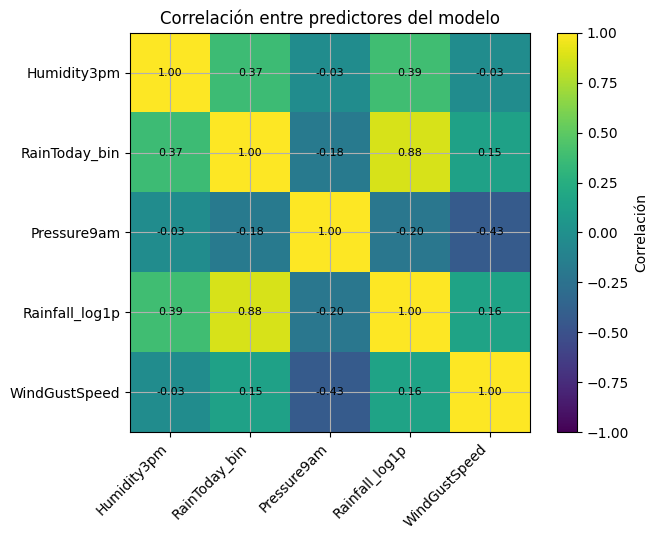

In [14]:
# Matriz de correlación de los predictores ya procesados
corr_predictors = X_train_processed.corr()
fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(corr_predictors, vmin=-1, vmax=1)
ax.set_xticks(range(len(FEATURES)))
ax.set_yticks(range(len(FEATURES)))
ax.set_xticklabels(FEATURES, rotation=45, ha="right")
ax.set_yticklabels(FEATURES)
for i in range(len(FEATURES)):
    for j in range(len(FEATURES)):
        ax.text(j, i, f"{corr_predictors.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, label="Correlación")
ax.set_title("Correlación entre predictores del modelo")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "predictor_correlation.png", dpi=180, bbox_inches="tight")
plt.show()

# 3. Evaluación de desempeño predictivo

## 3.1 Predicciones y matriz de confusión

Se generan probabilidades sobre el conjunto de prueba y se utiliza inicialmente el umbral convencional de **0,5**. Esta decisión permite evaluar el modelo base sin optimización posterior del umbral.

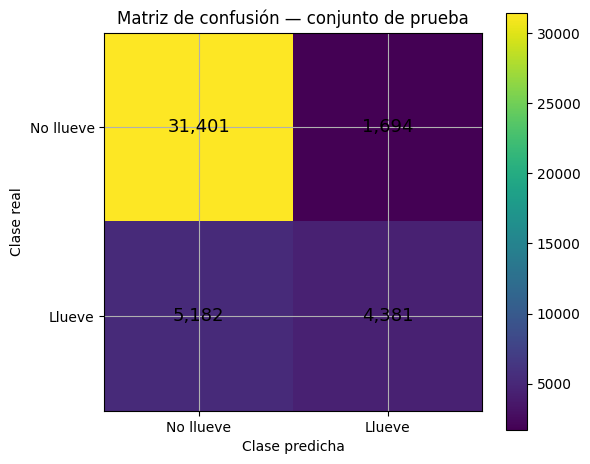

Verdaderos negativos (TN): 31,401
Falsos positivos (FP):     1,694
Falsos negativos (FN):     5,182
Verdaderos positivos (TP): 4,381


In [15]:
X_test_sm = sm.add_constant(X_test_processed, has_constant="add")
y_probability = logit_model.predict(X_test_sm)
THRESHOLD = 0.50
y_pred = (y_probability >= THRESHOLD).astype(int)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm)
for (i, j), value in np.ndenumerate(cm):
    ax.text(j, i, f"{value:,}", ha="center", va="center", fontsize=13)
ax.set_xticks([0, 1])
ax.set_xticklabels(["No llueve", "Llueve"])
ax.set_yticks([0, 1])
ax.set_yticklabels(["No llueve", "Llueve"])
ax.set_xlabel("Clase predicha")
ax.set_ylabel("Clase real")
ax.set_title("Matriz de confusión — conjunto de prueba")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrix.png", dpi=180, bbox_inches="tight")
plt.show()

print(f"Verdaderos negativos (TN): {tn:,}")
print(f"Falsos positivos (FP):     {fp:,}")
print(f"Falsos negativos (FN):     {fn:,}")
print(f"Verdaderos positivos (TP): {tp:,}")

## 3.2 Métricas de clasificación

- **Accuracy:** proporción total de predicciones correctas.
- **Precision:** de los días predichos con lluvia, cuántos efectivamente tuvieron lluvia.
- **Recall o sensibilidad:** de los días que realmente tuvieron lluvia, cuántos fueron detectados.
- **F1-score:** media armónica entre precision y recall.

Dado el desbalance de 22,4 %, la accuracy se compara con un clasificador trivial que siempre predice la clase mayoritaria.

In [16]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
specificity = tn / (tn + fp)
roc_auc = roc_auc_score(y_test, y_probability)
pr_auc = average_precision_score(y_test, y_probability)
baseline_accuracy = max(y_test.mean(), 1 - y_test.mean())

metrics_table = pd.DataFrame({
    "Métrica": [
        "Accuracy", "Precision", "Recall", "F1-score",
        "Especificidad", "Balanced accuracy", "ROC-AUC", "PR-AUC",
        "Accuracy baseline mayoritaria",
    ],
    "Valor": [
        accuracy, precision, recall, f1,
        specificity, balanced_accuracy, roc_auc, pr_auc,
        baseline_accuracy,
    ],
})
display(metrics_table.round(4))

print("Reporte de clasificación:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["No llueve", "Llueve"],
    digits=4,
))

,Métrica,Valor
0,Accuracy,0.8388
1,Precision,0.7212
2,Recall,0.4581
3,F1-score,0.5603
4,Especificidad,0.9488
5,Balanced accuracy,0.7035
6,ROC-AUC,0.8415
7,PR-AUC,0.6623
8,Accuracy baseline mayoritaria,0.7758


Reporte de clasificación:
              precision    recall  f1-score   support

   No llueve     0.8583    0.9488    0.9013     33095
      Llueve     0.7212    0.4581    0.5603      9563

    accuracy                         0.8388     42658
   macro avg     0.7898    0.7035    0.7308     42658
weighted avg     0.8276    0.8388    0.8249     42658



### Interpretación contextual de las métricas

Con umbral 0,5, el modelo alcanza una **accuracy aproximada de 83,9 %**, superior al 77,6 % del clasificador que siempre pronosticaría “no llueve”. La **precision cercana a 72,1 %** indica que, cuando el modelo anuncia lluvia, acierta en poco más de siete de cada diez casos.

El **recall de aproximadamente 45,8 %** revela la principal limitación: se detecta menos de la mitad de los días que realmente tendrán lluvia. El **F1-score cercano a 0,56** resume ese desequilibrio entre una precision razonable y una sensibilidad todavía moderada. En una aplicación donde omitir un día lluvioso sea costoso, S3 debería ajustar el umbral o ponderar la clase positiva.

## 3.3 Curva ROC y AUC

La curva ROC evalúa la relación entre sensibilidad y tasa de falsos positivos a través de todos los umbrales. Como guía descriptiva —no como regla absoluta— un AUC de 0,5 indica discriminación aleatoria; 0,7–0,8 suele considerarse aceptable; 0,8–0,9, buena; y sobre 0,9, excelente.

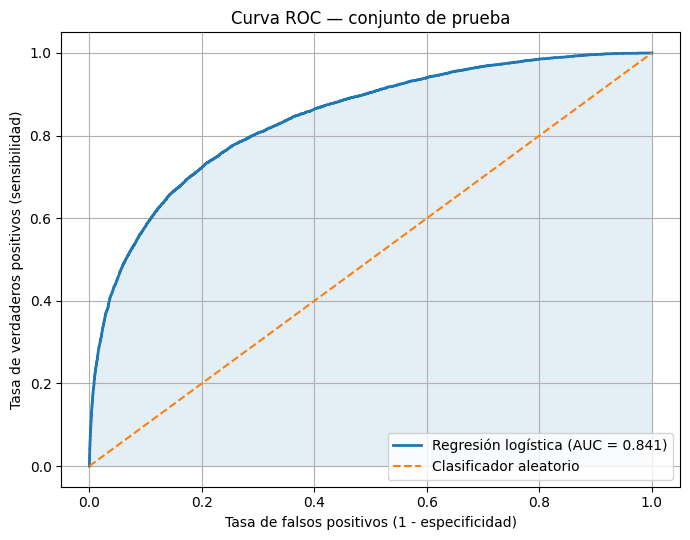

ROC-AUC = 0.8415
PR-AUC  = 0.6623 (métrica complementaria por desbalance)


In [17]:
fpr, tpr, thresholds = roc_curve(y_test, y_probability)

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.plot(fpr, tpr, linewidth=2, label=f"Regresión logística (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", label="Clasificador aleatorio")
ax.fill_between(fpr, tpr, alpha=0.12)
ax.set_xlabel("Tasa de falsos positivos (1 - especificidad)")
ax.set_ylabel("Tasa de verdaderos positivos (sensibilidad)")
ax.set_title("Curva ROC — conjunto de prueba")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "roc_curve.png", dpi=180, bbox_inches="tight")
plt.show()

print(f"ROC-AUC = {roc_auc:.4f}")
print(f"PR-AUC  = {pr_auc:.4f} (métrica complementaria por desbalance)")

### Interpretación del AUC

El **ROC-AUC de aproximadamente 0,841** se ubica en un rango de discriminación **bueno**. En términos probabilísticos, el modelo asigna una puntuación de riesgo mayor a un día lluvioso que a uno no lluvioso en cerca de 84 % de los pares comparados al azar.

El AUC muestra que el ordenamiento de riesgo es útil, aunque el recall con umbral 0,5 sea moderado. No existe contradicción: el modelo separa razonablemente las clases, pero el punto de corte actual es conservador para declarar lluvia.

# 4. Síntesis y reflexión

La Formativa 2 integró los resultados acumulados de S1 y S2 en un primer modelo predictivo reproducible. Desde S1 se heredaron la definición de `RainTomorrow` como objetivo binario, el desbalance de aproximadamente 22,4 %, el patrón de valores faltantes, la colinealidad extrema entre `MaxTemp` y `Temp3pm`, y el carácter asimétrico de `Rainfall` y `WindGustSpeed`. Estas observaciones evitaron seleccionar variables solo por disponibilidad: se excluyeron `Sunshine` y `Evaporation` por su alta ausencia, no se combinaron las temperaturas casi duplicadas y se transformó `Rainfall` con `log1p` en lugar de eliminar como “outliers” una gran cantidad de días con lluvia real.

S2 aportó la validación metodológica. Las correlaciones de `Humidity3pm`, `RainToday_bin`, `Pressure9am` y `Rainfall` mantuvieron su signo en 10.000 remuestras bootstrap, y los parámetros de `Humidity3pm`, `WindGustSpeed` y la proporción de lluvia fueron consistentes entre métodos clásicos y de remuestreo. Con esa evidencia se seleccionaron cinco predictores: humedad de la tarde, lluvia actual, presión matinal, lluvia transformada y velocidad de ráfaga. La imputación se realizó con mediana para continuas y moda para la binaria, ajustando todo únicamente en entrenamiento. La partición 70/30 fue estratificada y las continuas se estandarizaron.

El modelo logístico fue estadísticamente coherente: todos los predictores resultaron significativos y los VIF permanecieron bajo 3, sin evidencia de multicolinealidad problemática. `Humidity3pm` fue la señal dominante, mientras que `Pressure9am` mostró un efecto protector. En prueba, el modelo obtuvo una accuracy cercana a 83,9 %, precision de 72,1 %, recall de 45,8 %, F1 de 0,56 y ROC-AUC de 0,841. El AUC evidencia buena capacidad de discriminación y supera claramente un ordenamiento aleatorio; sin embargo, el umbral 0,5 deja sin detectar más de la mitad de los días lluviosos. Por eso la evaluación no puede basarse exclusivamente en accuracy.

De cara a S3, las mejoras prioritarias son comparar imputación simple con alternativas más informativas, ajustar o validar el umbral según el costo de falsos negativos, incorporar ponderación de clases, reportar PR-AUC, evaluar regularización y modelos con interacciones o no linealidad, y validar estabilidad de coeficientes mediante bootstrap. Además, una partición temporal o agrupada por `Location` sería metodológicamente más realista que una división aleatoria, porque las observaciones de una misma estación y fechas cercanas no son completamente independientes. Esta formativa deja una línea base interpretable sobre la cual comparar modelos más completos sin perder coherencia con S1 y S2.

# 5. Verificación final y checklist de entrega

- [x] Dataset de S1/S2 cargado y objetivo documentado.
- [x] Hallazgos de S1 y S2 incorporados explícitamente.
- [x] Tratamiento de faltantes justificado y sin fuga de información.
- [x] Tratamiento robusto de `Rainfall` mediante `log1p`.
- [x] División estratificada 70/30.
- [x] Cinco predictores justificados.
- [x] Regresión logística con resumen, coeficientes, odds ratios y p-valores.
- [x] Diagnóstico VIF.
- [x] Matriz de confusión, accuracy, precision, recall y F1-score.
- [x] Curva ROC y AUC interpretados.
- [x] Síntesis final conectada con S1, S2 y mejoras para S3.
- [x] Notebook ejecutado de principio a fin sin errores.

## Bibliografía base

- Efron, B., & Tibshirani, R. J. (1993). *An Introduction to the Bootstrap*. Chapman & Hall/CRC.
- Hosmer, D. W., Lemeshow, S., & Sturdivant, R. X. (2013). *Applied Logistic Regression* (3.ª ed.). Wiley.
- James, G., Witten, D., Hastie, T., & Tibshirani, R. (2013). *An Introduction to Statistical Learning*. Springer.
- Kaggle. (2017). *Rain in Australia / WeatherAUS* [Conjunto de datos].
- Maidana González, J. P. (2026). Materiales del curso MCDI501. Universidad Andrés Bello.
- Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.
- Seabold, S., & Perktold, J. (2010). Statsmodels: Econometric and Statistical Modeling with Python. *Proceedings of the 9th Python in Science Conference*, 92–96.

In [18]:
final_summary = {
    "n_modeling": int(len(df)),
    "n_train": int(len(X_train)),
    "n_test": int(len(X_test)),
    "positive_rate_test": float(y_test.mean()),
    "threshold": THRESHOLD,
    "accuracy": float(accuracy),
    "precision": float(precision),
    "recall": float(recall),
    "f1": float(f1),
    "roc_auc": float(roc_auc),
    "pr_auc": float(pr_auc),
    "max_vif": float(max_vif),
    "model_converged": bool(logit_model.mle_retvals.get("converged", False)),
}

pd.Series(final_summary).to_frame("resultado")

,resultado
n_modeling,142193
n_train,99535
n_test,42658
positive_rate_test,0.2242
threshold,0.5000
accuracy,0.8388
precision,0.7212
recall,0.4581
f1,0.5603
roc_auc,0.8415
